In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from adjustText import adjust_text
import seaborn as sns

#loading the dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
df_DA_US =df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

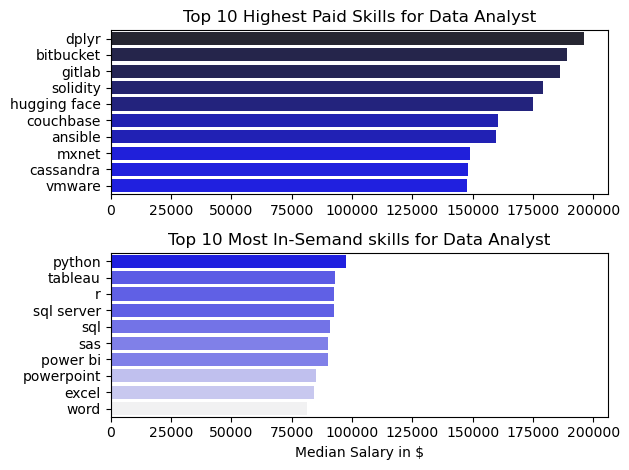

In [7]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US[['salary_year_avg' , 'job_skills']]
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_da_top_pay = df_DA_US_group.sort_values(by = 'median', ascending=False).head(10)

df_DA_skills = df_DA_US_group.sort_values(by='count', ascending= False).head(10).sort_values(by = 'median', ascending=False)

fig, ax = plt.subplots(2,1)
sns.barplot(data=df_da_top_pay, x='median', y=df_da_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most In-Semand skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary in $')
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()
plt.show()

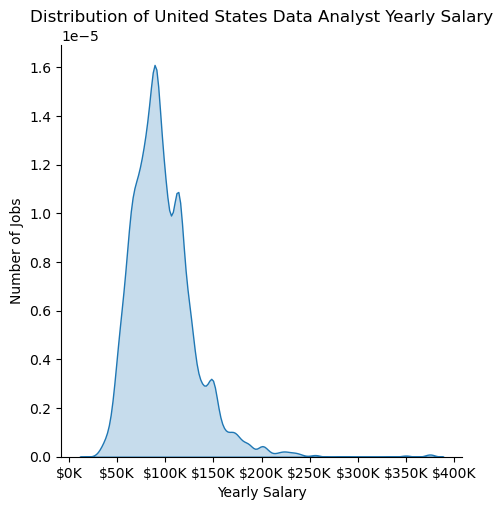

In [12]:
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill= True)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of United States Data Analyst Yearly Salary')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

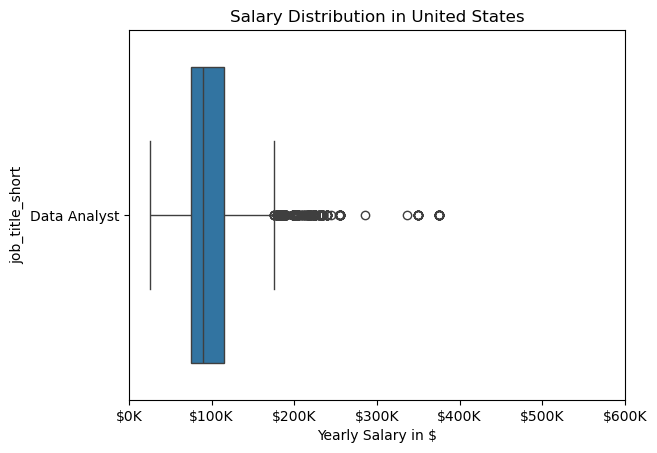

In [14]:

sns.boxplot(data=df_DA_US, x='salary_year_avg', y='job_title_short')
plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary in $')
ax= plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()